The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
=== NẠP DỮ LIỆU THÀNH CÔNG VỚI ĐỦ CÁC CỘT CẦN THIẾT ===
=== THỐNG KÊ MÔ TẢ CHI TIẾT ===
              count           mean            std           min           25%  \
Open         2191.0   63835.469252    9583.725476  41269.527545  58704.802860   
High         2191.0   64509.304004    9805.010705  41390.634248  59327.104729   
Low          2191.0   63120.014657    9350.154406  41271.109784  58185.868094   
Close        2191.0   63730.133803    9548.904625  41319.284180  58682.367188   
Volume       2191.0  573450.231515  616436.500886      0.000000      0.000000   
Log_Return   2191.0       0.000102       0.015463     -0.072466     -0.003388   
Day_of_Week  2191.0       3.000000       2.000457      0.000000      1.000000   

                       50%            75%           max  skewness  kurtosis  
Open          64891.120512   70328.316637  8.765946e+04 -0.507876 -0.159190  
High          65303

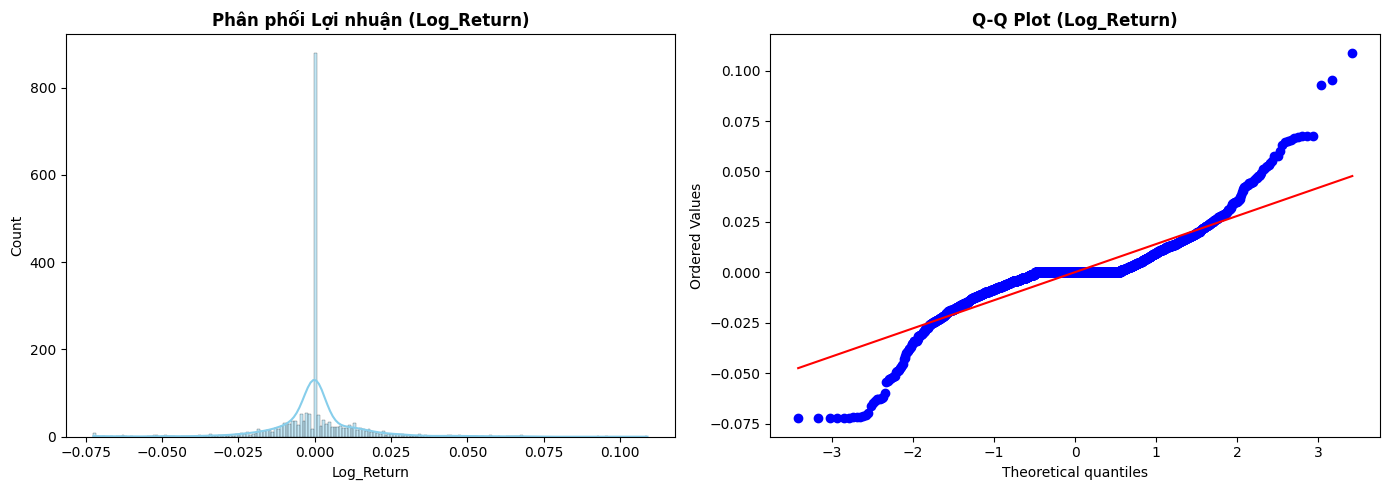

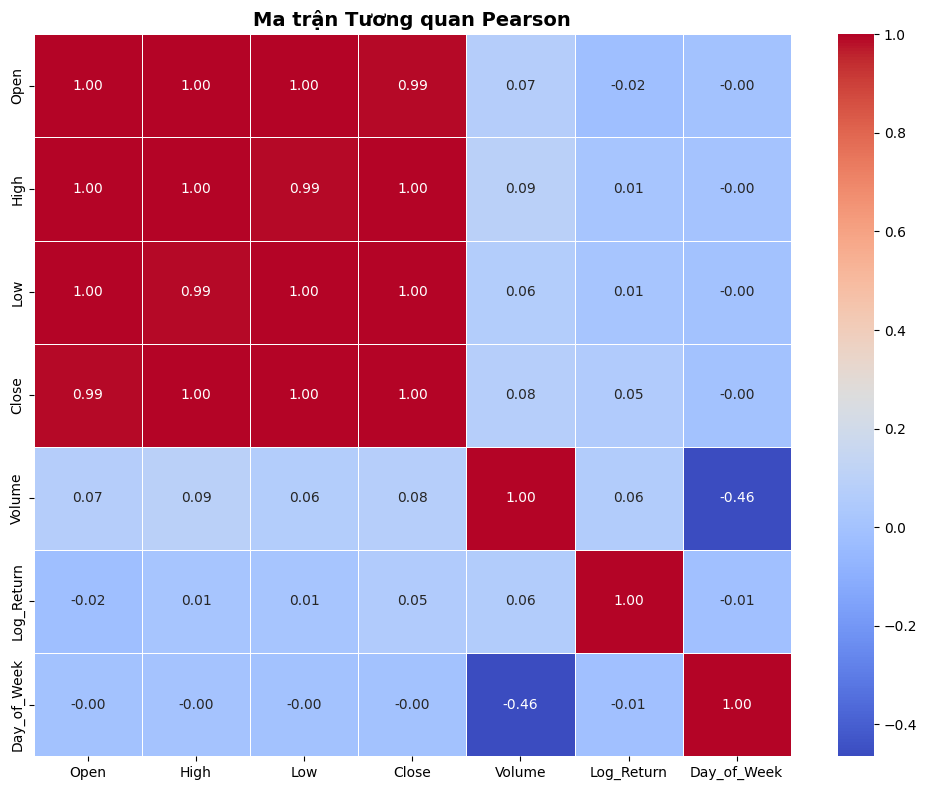

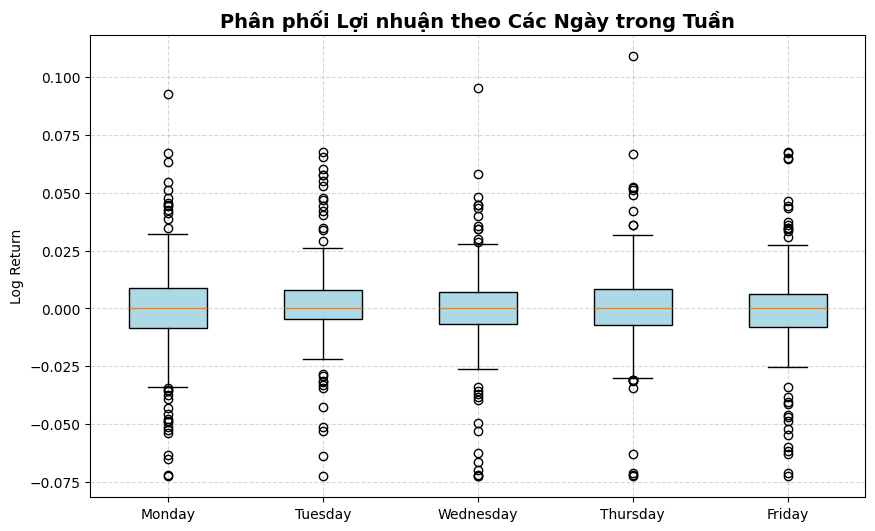

BÁO CÁO PHÂN TÍCH MÙA VỤ & KIỂM ĐỊNH THỐNG KÊ
Kiểm định ANOVA F-test (F-stat = 0.7032): p-value = 0.5897
Kiểm định Kruskal-Wallis (H-stat = 3.1902): p-value = 0.5265
--------------------------------------------------------------------------------
1. Nhận xét: p-value > 0.05 ở kiểm định Kruskal-Wallis.
2. Giải thích: Không có bằng chứng thống kê cho thấy trung bình lợi nhuận giữa các ngày có sự khác biệt.
3. Ý nghĩa: Hiệu ứng 'Day-of-the-Week' (ví dụ: Monday Effect) không đủ mạnh để khai thác.
4. Kết luận: KHÔNG NÊN dựa vào yếu tố Ngày trong tuần làm tín hiệu giao dịch độc lập.



In [ ]:
# Cell 1: Import và Nạp Dữ liệu Cleaned
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))
from utils.eda_analyzer import FinancialEDA

# 1. Nạp dữ liệu GAS đã tiền xử lý từ Notebook 03
df_clean = pd.read_parquet("../data/processed/GAS_cleaned.parquet")

# 2. Tạo bổ sung các cột bắt buộc cho phân tích mùa vụ (Seasonality & ANOVA)
# Tính Log Return nếu chưa có
if "Log_Return" not in df_clean.columns:
    df_clean["Log_Return"] = np.log(df_clean["Close"] / df_clean["Close"].shift(1))

# Đảm bảo index là Datetime
df_clean.index = pd.to_datetime(df_clean.index)

# Trích xuất Thứ trong tuần từ Index
if "Day_of_Week" not in df_clean.columns:
    df_clean["Day_of_Week"] = df_clean.index.dayofweek

# Loại bỏ dòng đầu tiên bị NaN do dịch chuyển shift(1)
df_clean.dropna(inplace=True)

# 3. Khởi tạo mô-đun EDA
eda = FinancialEDA(df_clean, target_col="Close")
print("=== NẠP DỮ LIỆU THÀNH CÔNG VỚI ĐỦ CÁC CỘT CẦN THIẾT ===")

# Cell 2: In Báo cáo Thống kê Mô tả Tổng quan
stats_summary = eda.summary_overview()
print("=== THỐNG KÊ MÔ TẢ CHI TIẾT ===")
print(stats_summary)

# Cell 3: Bộ Biểu đồ Phân phối Chi tiết cho Log Return
eda.plot_distribution_suite(col="Log_Return")

# Cell 4: Phân tích Ma trận Tương quan Đa phương pháp
eda.plot_correlations()

# Cell 5: Phân tích Mùa vụ & Kiểm định ANOVA / Kruskal-Wallis
eda.plot_seasonality_and_anova()

# Cell 6: Phân tích Tương quan Mùa vụ dài hạn (Day of Year vs Profit)
print("\n=== TƯƠNG QUAN GIỮA NGÀY TRONG NĂM VÀ LỢI NHUẬN ===")
eda.plot_day_of_year_vs_profit(period=60)

# Cell 7: Phân tích Tương quan Chỉ báo Kỹ thuật (MACD vs Profit)
print("\n=== TƯƠNG QUAN GIỮA MACD VÀ LỢI NHUẬN ===")
eda.plot_macd_vs_profit(period=60)